# 🚀 Usage Example of SRGAN Framework

Welcome to this interactive **SRGAN Framework** notebook!  
It will guide you through the essential steps to get started with super-resolving remote-sensing imagery 🌍✨

## 📋 What You’ll Learn
- 📦 **Install** the package and required dependencies  
- 🧠 **Instantiate** pretrained models  
- 🧪 **Run** inference on test data  
- 🔧 **Train** your own models and use them  

---

> 💡 **Note:** Make sure to run this notebook in a **Google Colab GPU environment** ⚙️💥  
> You can activate it via  
> **Runtime → Change runtime type → Hardware accelerator → GPU**


## 1. Install `opensr-srgan` package from PyPi
When you install the package, the dependency checker should automatically install the correct versions of dependencies.

In [1]:
!pip install opensr_srgan  --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 131.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 53.0 MB/s eta 0:00:00


In [2]:
# @title Utility Definitions - some local helpers
import torch
import requests
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from importlib import resources

def download_example_batch():
  # Downloads an Example Batch
  r = requests.get("https://huggingface.co/simon-donike/SR-GAN/resolve/main/example_batch_RGBNIR.pt")
  with open(f"example_batch_RGBNIR.pt", "wb") as f:
      f.write(r.content) # save to file
  batch = torch.load("example_batch_RGBNIR.pt") # read file
  lr,hr = batch["lr"][:3,:,:,:],batch["hr"][:3,:,:,:] # extract tensors, only 2
  print("Downloaded Sentinel-2 Example batch!")
  print("LR Shape:",lr.shape," - HR shape:",hr.shape)
  print("Image value range:",round(lr.min().item(),3), " - " , round(lr.max().item(),3))
  return lr,hr

def plot_triplet(lr, sr, hr):
    """Plot 3 example triplets (LR, SR, HR) side by side."""
    # Stretch for visualization
    lr, sr, hr = (lr * 4).clamp(0, 1), (sr * 4).clamp(0, 1), (hr * 4).clamp(0, 1)
    lr = lr[:,:,:64,:64]
    sr = sr[:,:,:256,:256]
    hr = hr[:,:,:256,:256]

    tensors = [lr, sr, hr]
    titles = ["LR", "SR", "HR"]

    n_examples = min(3, lr.shape[0])  # show up to 3 samples
    fig, axes = plt.subplots(n_examples, 3, figsize=(9, 3 * n_examples))

    for i in range(n_examples):
        for j, (tensor, title) in enumerate(zip(tensors, titles)):
            img = tensor[i, :3].permute(1, 2, 0).detach().cpu().numpy()
            ax = axes[i, j] if n_examples > 1 else axes[j]
            ax.imshow(img)
            if i == 0:
                ax.set_title(title, fontsize=12)
            ax.axis("off")

    plt.tight_layout()
    plt.show()


def find_logs():
  # Static lookup in the logs folder created by training
  from pathlib import Path
  logs_root = Path("/content/logs")

  ckpt_matches = sorted(logs_root.rglob("last.ckpt"))
  config_matches = sorted(logs_root.rglob("config.yaml"))

  if not ckpt_matches:
      raise FileNotFoundError("Could not find last.ckpt under ./logs/")
  if not config_matches:
      raise FileNotFoundError("Could not find config.ckpt under ./logs/")

  ckpt_path = ckpt_matches[-1]
  config_path = config_matches[-1]

  print("Loading freshly trained model")
  print(f"Using checkpoint: {ckpt_path}")
  print(f"Using config:     {config_path}")
  return (ckpt_path,config_path)


In [3]:
# Lets check the version quickly
import opensr_srgan
opensr_srgan.__version__

'0.5.1'

## 🔍 2. Inference

In this section, you’ll learn how to **instantiate** your own trained models 🧠 or **load pretrained** ones from the SRGAN framework cloud 📦 for immediate inference.

---

### 📥 2.1 Get Pretrained/Preconfigured Models

The following pretrained models are currently available:

- 🟩 **Sentinel-2 RGB-NIR SR** — 4-band **4×** model for **Sentinel-2**-like image super-resolution of 10 m bands → **2.5 m**
- 🟪 **Sentinel-2 SWIR SR** — 6-band **8×** model for **Sentinel-2**-like image super-resolution of 20 m bands → **2.5 m**

Pretrained and preconfigured Models are **automatically downloaded and instantiated** when calling  
```python
load_inference_model("RGB-NIR")
load_inference_model("SWIR")
```
✨ No manual setup needed!


In [4]:
# Get pre-configured model including weights
from opensr_srgan import load_inference_model
model = load_inference_model("RGB-NIR").to("cuda")

config_RGB-NIR.yaml:   0%|          | 0.00/1.51k [00:00<?, ?B/s]

RGB-NIR_4band_inference.ckpt: reconstructing file:   0%|          |  0.00B / 47.1MB            

RGB-NIR_4band_inference.ckpt: downloading bytes:           |  0.00B            

After the model has been created, please use the pytorch-lightning native `predict_step` function. Sticking to the pytorch-lightning workflow includes the selected normalization procedures that the model was trained on, and also seamlessly enables multi-GPU processing and other tweaks.  
  
In this example, we load an example image from hugging-face and test the inference on that.


In [5]:
# download example data
lr,hr = download_example_batch()

Downloaded Sentinel-2 Example batch!
LR Shape: torch.Size([3, 4, 128, 128])  - HR shape: torch.Size([3, 4, 512, 512])
Image value range: 0.015  -  0.619


In [6]:
# Super-Resolve LR image - use PL predict_step
with torch.inference_mode():
  sr = model.predict_step(lr)

Let's plot the LR,SR and HR images to see the result

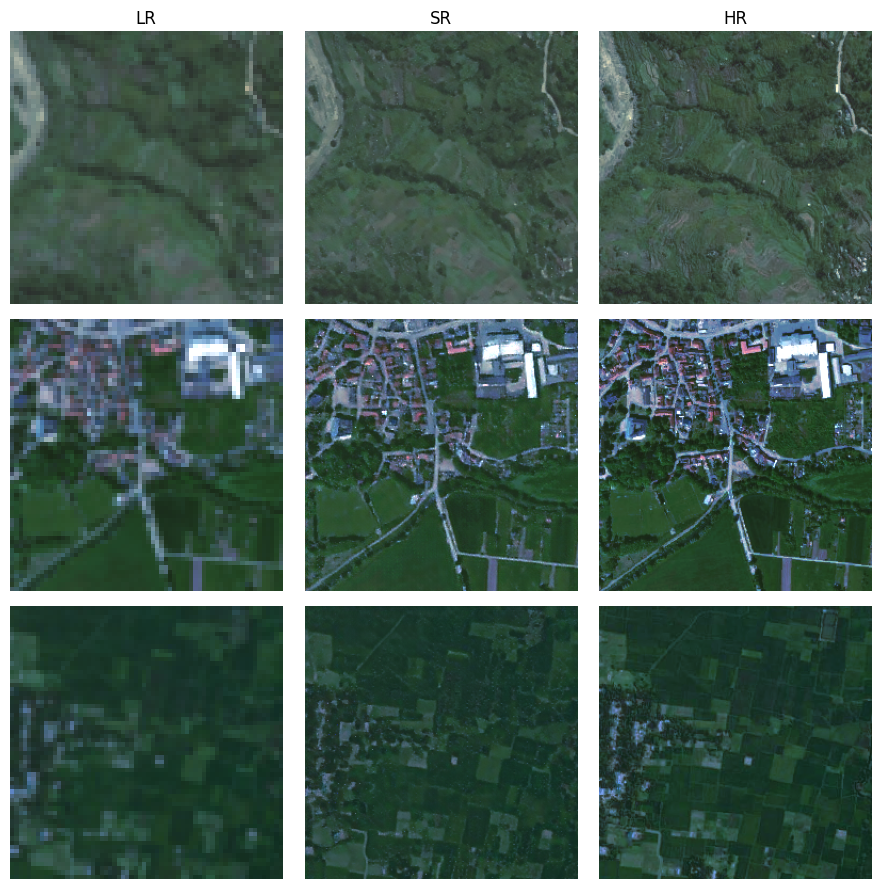

In [7]:
# plot images using utility function
plot_triplet(lr,sr,hr)

### 2.2: Create your own Inference Model
In an operational workflow, after you trained your own model, you can use the `load_from_config` function to recreate your model.

You need to pass:


*   The config file you used to train your model (so that the architechture is recreated), and
*   the model checkpoint

You can upload these files here in the notebook environment to load them and test this functionality. When you start a training run, the config file and the checkpoints that are automatically generated and updated based on validation performance are saved to the same folder!







```python
from opensr_srgan import load_from_config
model = load_from_config(config_path="YOUR_CONFIG_PATH",checkpoint_uri="YOUR_CHECKPOINT_PATH")
```



# 3. Training
In orer to demonstrate the training process, we need to download the example dataset locally.  
Follow the instructions in the documentation on how to add your own data, but fundamentally you just need a `torch.utils.data.Dataset` class which returns a tuple of LR,HR tensors.

In [8]:
from opensr_srgan.data.example_data.download_example_dataset import get_example_dataset
get_example_dataset("example_dataset/")

📦 Downloading from Hugging Face Hub...


example_dataset.zip: reconstructing file:   0%|          |  0.00B /  240MB            

example_dataset.zip: downloading bytes:           |  0.00B            

✅ Extracted dataset to: /content/example_dataset


The second element we need is the `config.yaml` file, which in this case we download from the GitHub repo. In order to run your own experiments, get familiar with the options and functionalities of the config file, and create your own for a perticular experiment.

In [9]:
# Load config straight from package
with resources.files("opensr_srgan.configs").joinpath("config_training_example.yaml").open("r") as f:
    config = OmegaConf.load(f)

# Lets print the config nicely to examine the arcitechture
from pprint import pprint
pprint(OmegaConf.to_container(config, resolve=True))

{'Data': {'dataset_type': 'ExampleDataset',
          'normalization': 'normalise_10k',
          'num_workers': 1,
          'prefetch_factor': 2,
          'train_batch_size': 2,
          'val_batch_size': 2},
 'Discriminator': {'base_channels': 32,
                   'linear_size': 1024,
                   'model_type': 'standard',
                   'n_blocks': 2,
                   'use_spectral_norm': False},
 'Generator': {'block_type': 'rrdb',
               'growth_channels': 32,
               'large_kernel_size': 9,
               'model_type': 'SRResNet',
               'n_blocks': 4,
               'n_channels': 32,
               'res_scale': 0.2,
               'scaling_factor': 4,
               'small_kernel_size': 3},
 'Logging': {'num_val_images': 5,
             'wandb': {'enabled': False,
                       'entity': 'opensr',
                       'project': 'SRGAN_10m'}},
 'Model': {'continue_training': False, 'in_bands': 4, 'load_checkpoint': False},
 'Opt

Then, we can pass the config to the train function which runs our training. The results, including the trained weights as well as the config ffile (which you can later use to re-instanciate the model), will be saved in the local `logs/` folder.

In [10]:
from opensr_srgan.train import train
config.Training.max_epochs = 10 # override max epochs to something sane
train(config) # Start Training

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 172MB/s]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


WARNING -- Using Example Dataset!
This dataset is exclusively meant for demonstration and debugging, not training or evaluation.
Please use a proper dataset for any serious work.
Created Dataset type ExampleDataset with 180 training samples and 20 validation samples.

Not using Weights & Biases logging, reduced CSV logs written locally.
Experiment Path: logs/SRGAN_10m/2026-07-23_12-07-57


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/logs/SRGAN_10m/2026-07-23_12-07-57 exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                       ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ generator                  │ FlexibleGenerator    │  824 K │ train │     0 │
│ 1 │ discriminator              │ Discriminator        │  2.4 M │ train │     0 │
│ 2 │ content_loss_criterion     │ GeneratorContentLoss │ 20.0 M │ train │     0 │
│ 3 │ adversarial_loss_criterion │ BCEWithLogitsLoss    │      0 │ train │     0 │
└───┴────────────────────────────┴──────────────────────┴────────┴───────┴───────┘

...

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


🚀  SRGAN Model Summary
🧩 Generator
   • Architecture:      SRResNet (RRDB Dense Residual Blocks)
   • Resolution:        Super-Resolution Factor: ×4
   • Input Channels:    4
   • Feature Channels:  32
   • Residual Blocks:   4
   • Kernel Sizes:      small=3, large=9
   • Params:            0.82 M

🧠 Discriminator
   • Architecture:     SRGAN
   • Blocks/Layers:    2
   • Base Channels:    64
   • Kernel Size:      3
   • FC Layer Size:    1024
   • Params:            2.40 M

⚙️  Training Configuration
   • Pretrain Generator: True
   • Pretrain Steps:     1000
   • Adv. Ramp Steps:    500
   • Label Smoothing:    True
   • Adv. Target Label:  0.9

🔁 Exponential Moving Average (EMA)
   • Enabled:           False

📉 Loss Functions
   • Content Loss:       GeneratorContentLoss
   • Adversarial Loss:   BCEWithLogitsLoss
   • Content: 1.0 | Adversarial: 0.001

📊 Model Summary
   • Total Params:           3.22 M
   • Total Trainable Params: 3.22 M
   • Device:                 cuda:0



/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:538: Found 38 module(s) in eval mode at
the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore
this warning.

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_metrics/l1 improved. New best score: 0.043
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_metrics/l1 improved by 0.005 >= min_delta = 0.0. New best score: 0.038
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_metrics/l1 improved by 0.001 >= min_delta = 0.0. New best score: 0.037
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_metrics/l1 improved by 0.006 >= min_delta = 0.0. New best score: 0.031
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_metrics/l1 improved by 0.005 >= min_delta = 0.0. New best score: 0.026
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_metrics/l1 improved by 0.000 >= min_delta = 0.0. New best score: 0.026
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_metrics/l1 improved by 0.002 >= min_delta = 0.0. New best score: 0.025
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_metrics/l1 improved by 0.002 >= min_delta = 0.0. New best s

Lets now load your trained model and run inference on an image. Sure, the model probably didn't converge, and we're using an image from the trainig set, but lets just test if the outputs are starting to show some structure.

Loading freshly trained model
Using checkpoint: /content/logs/SRGAN_10m/2026-07-23_12-07-57/last.ckpt
Using config:     /content/logs/SRGAN_10m/2026-07-23_12-07-57/config.yaml


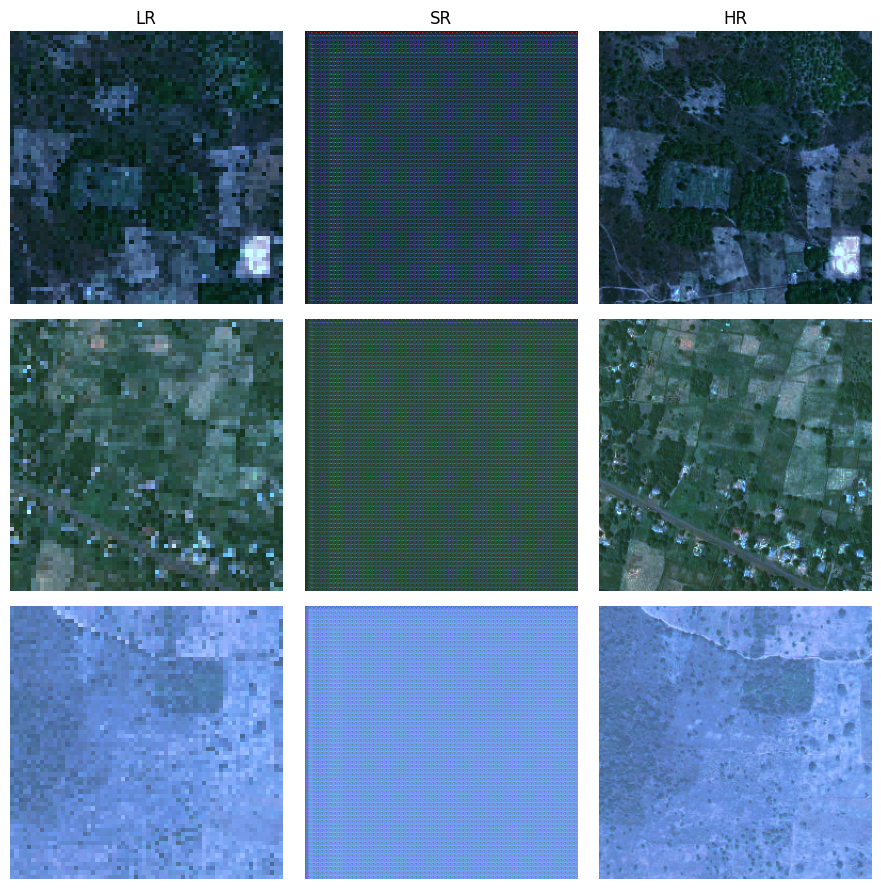

In [11]:
# Find ckpt and config
ckpt_path, config_path = find_logs()

# Get model
from opensr_srgan import load_from_config
device = "cuda" if torch.cuda.is_available() else "cpu"
model = load_from_config(
    config_path=str(config_path),
    checkpoint_uri=str(ckpt_path),
    map_location= device,
).eval()

# Load three training examples from the same example dataset
from opensr_srgan.data.example_data.example_dataset import ExampleDataset
dataset = ExampleDataset("example_dataset/")
samples = [dataset[i] for i in [10,11,12]]
lr = torch.stack([x[0] for x in samples], dim=0)
hr = torch.stack([x[1] for x in samples], dim=0)

# Run SR
with torch.inference_mode():
    sr = model.predict_step(lr.to(device))

# Plot Outputs
plot_triplet(lr.cpu(), sr.cpu(), hr.cpu())

That's it! If you have any questions or issues, please feel free to create an Issue at https://github.com/ESAOpenSR/SRGAN

If you use this code in your work, please cite:
```bibtex
@article{donike2025opensr,
  title={OpenSR-SRGAN: A Flexible Super-Resolution Framework for Multispectral Earth Observation Data},
  author={Donike, Simon and Aybar, Cesar and Contreras, Julio and G{\'o}mez-Chova, Luis},
  journal={arXiv preprint arXiv:2511.10461},
  year={2025}
}
```